# Part A

In [1]:
#import packages & modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats

In [2]:
#import datasets
df_beach = pd.read_csv('beach_amenities.csv')
df_climate = pd.read_csv('climate_summary_by_region.csv')
df_no_nsw = pd.read_csv('data_except_nsw.csv')
df_yes_nsw = pd.read_csv('data_nsw.csv')

## beach_amenities.csv

### 1. Explore the data before cleaning

In [3]:
#explore data before cleaning
df_beach.info() #car_spaces dtype is object now ==> might need to change to int
df_beach.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         303 non-null    object
 1   Has_Toilet   303 non-null    object
 2   Has_Showers  294 non-null    object
 3   BBQ          303 non-null    object
 4   Playground   303 non-null    object
 5   Car_Spaces   303 non-null    object
dtypes: object(6)
memory usage: 14.3+ KB


,Name,Has_Toilet,Has_Showers,BBQ,Playground,Car_Spaces
0,Wonthaggi Basin Rockpool,No,No,No,No,5
1,Royal National Park Garie Beach,Yes,No,Yes,Yes,5
2,Surf Beach VIC,No,No,No,No,19
3,Currumbin Beach,Yes,Yes,Yes,Yes,55
4,Mooloolaba Beach,Yes,Yes,Yes,Yes,70


In [4]:
# The Name column has only 301 unique values ==> might have 2 duplicated values ==> check if the duplication is appropriate
# Based on the info() and describe() result, the non-null count matches the total count of each column ==> no null value
# except for has_showers (has only 294 non-null values)
# Playground has 4 unique values, which is strange considering it should contain only Yes and No values. 

df_beach.describe()

,Name,Has_Toilet,Has_Showers,BBQ,Playground,Car_Spaces
count,303,303,294,303,303,303
unique,301,2,2,2,4,38
top,Short Point Beach,Yes,No,Yes,No,0
freq,2,214,201,167,153,24


In [5]:
# Check the percentage of null values for Has_Showers and since it is less < 50%, don't drop the column or row. 
df_beach.isnull().mean() * 100

Name           0.000000
Has_Toilet     0.000000
Has_Showers    2.970297
BBQ            0.000000
Playground     0.000000
Car_Spaces     0.000000
dtype: float64

In [6]:
# Check duplicates
df_beach[df_beach.duplicated()]

,Name,Has_Toilet,Has_Showers,BBQ,Playground,Car_Spaces
123,Turners Beach Yamba,Yes,No,No,No,13
301,Short Point Beach,No,No,No,No,12


In [7]:
# check inconsistent data 
df_beach['Playground'].unique() #True should be replaced by Yes. And remove trailing spaces for 'Yes '

array(['No', 'Yes', 'True', 'Yes '], dtype=object)

In [8]:
# check unique value for car_spaces
df_beach['Car_Spaces'].unique() #replace 100? with 100. 30-50 is not really meaningful, can be replaced with a null value

array(['5', '19', '55', '70', '0', '6', '30-50', '20', '40', '50', '12',
       '25', '16', '130', '8', '14', '45', '9', '11', '30', '120', '35',
       '13', '90', '10', '18', '15', '100?', '7', '17', '80', '140',
       '170', '190', '160', '60', '180', '110'], dtype=object)

In [9]:
# Check uniqueness for the Name column
df_beach['Name'].unique()

array(['Wonthaggi Basin Rockpool', 'Royal National Park Garie Beach',
       'Surf Beach VIC', 'Currumbin Beach', 'Mooloolaba Beach',
       'Clare Valley Quarry Swim', 'Manly Harbour Swim Spot QLD',
       'Middleton Surf Beach', 'Crystal Creek Swimming Hole',
       'City Beach Perth', 'Henley South Beach', 'Clovelly Ocean Pool',
       'Safelink Cove Swim', 'Hyams Beach', 'Lake Bonney Barmera',
       'Horseshoe Bay Port Elliot', 'Coogee Beach',
       'Gordon Dam Lake Gordon', 'Port Vincent Swimming Enclosure',
       'Bondi Icebergs Pool', 'King George Sound Swim Spot',
       'Wanda Beach', 'Clifton Beach', 'Alva Beach', 'Manuka Pool',
       'Venus Bay Main Beach', 'Killen Falls Swimming Hole',
       'Burns Beach', 'Horseshoe Bay Magnetic Island', 'Macmasters Beach',
       'Paynesville Swim Beach', 'Tathra Beach', 'Airlie Main Beach',
       'Pambula Beach', 'Bondi Beach', '1770 Foreshore',
       'Batemans Bay Swim Enclosure', 'Inverloch Main Beach',
       'Urangan Pier Beac

### 2. Clean the data

In [10]:
# drop duplicates
df_beach['Name'] = df_beach['Name'].drop_duplicates()

In [11]:
# remove whitespace
df_beach['Playground'] = df_beach['Playground'].str.strip()

# replace value
df_beach['Playground'] = df_beach['Playground'].replace({'True' : 'Yes'})

In [12]:
# replace 100? with 100
df_beach['Car_Spaces'] = df_beach['Car_Spaces'].replace({'100?' : '100'})

# Replace 30-50 with a null value
df_beach['Car_Spaces'] = df_beach['Car_Spaces'].replace({'30-50' : None})

In [13]:
# Since there are too many values, can not manually check the existence of whitespaces ==> Trim just in case. 
df_beach['Name'] = df_beach['Name'].str.strip()

In [14]:
# Change Car_Spaces dtype from object to numeric
df_beach['Car_Spaces'] = pd.to_numeric(df_beach['Car_Spaces'], errors = 'coerce') # since there is nan value ==> float
# but it's not meaningful ==> change to int

In [15]:
# Convert Car_Spaces value from float to int
df_beach['Car_Spaces'] = df_beach['Car_Spaces'].astype('Int64')

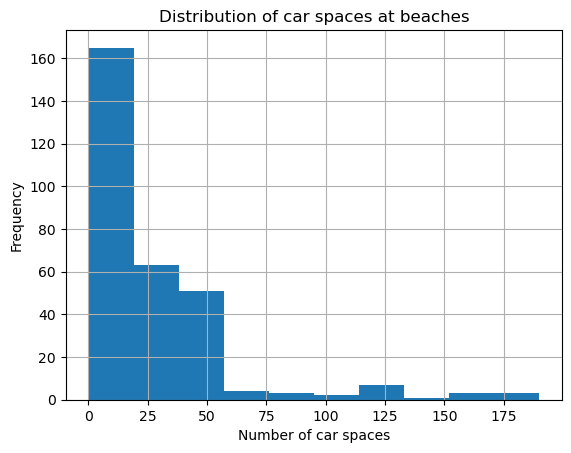

In [16]:
# Check outliners 
df_beach.hist(column = 'Car_Spaces')
plt.xlabel('Number of car spaces')
plt.ylabel('Frequency')
plt.title('Distribution of car spaces at beaches')
plt.show()

In [17]:
# Change Yes or No value to a boolean for future analysis
df_beach['Has_Showers'] = df_beach['Has_Showers'].replace({'Yes' : True, 'No' : False})
df_beach['Has_Toilet'] = df_beach['Has_Toilet'].replace({'Yes' : True, 'No' : False})
df_beach['Playground'] = df_beach['Playground'].replace({'Yes' : True, 'No' : False})
df_beach['BBQ'] = df_beach['BBQ'].replace({'Yes' : True, 'No' : False})

C:\Users\linhc\AppData\Local\Temp\ipykernel_47956\3294610890.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_beach['Has_Toilet'] = df_beach['Has_Toilet'].replace({'Yes' : True, 'No' : False})
C:\Users\linhc\AppData\Local\Temp\ipykernel_47956\3294610890.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_beach['Playground'] = df_beach['Playground'].replace({'Yes' : True, 'No' : False})
C:\Users\linhc\AppData\Local\Temp\ipykernel_47956\3294610890.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will

In [18]:
# Convert Has_Showers to a boolean (not bool, otherwise will lose null value)

df_beach['Has_Showers'] = df_beach['Has_Showers'].astype('boolean')

## climate_summary_by_region.csv

### 1. Explore the data before cleaning

In [19]:
df_climate.head(100)

,Region_Name,Avg_Summer_Temp_C,Avg_Winter_Temp_C,Annual_Rainfall_mm,Avg_UV_Index,Extreme_Heat_Days,Avg_Sea_Temp_C
0,Adelaide,29.5,14.8,469,9.1,9,23.0
1,Atherton Tablelands,29.6,20.0,1537,7.3,2,20.8
2,Bass Coast,29.9,16.1,540,9.5,25,23.2
3,Bellarine,32.6,13.1,1775,9.8,0,21.3
4,Border,27.3,16.1,608,10.6,8,25.4
...,...,...,...,...,...,...,...
64,Sydney,27.4,13.3,377,10.2,2,24.2
65,West Coast,24.7,15.3,1087,7.6,21,19.7
66,Whitsundays,24.4,13.5,1193,8.9,18,27.6
67,Wilson Prom,30.4,10.3,558,5.0,16,25.9


In [20]:
df_climate.info() #currently, no null value # 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Region_Name         69 non-null     object 
 1   Avg_Summer_Temp_C   69 non-null     float64
 2   Avg_Winter_Temp_C   69 non-null     float64
 3   Annual_Rainfall_mm  69 non-null     int64  
 4   Avg_UV_Index        69 non-null     float64
 5   Extreme_Heat_Days   69 non-null     int64  
 6   Avg_Sea_Temp_C      69 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 3.9+ KB


In [21]:
df_climate.describe(include = 'all') # For annual_rainfall_mm, the allowed value is 200-2000, as written in the
# glossary, but the max here is 2360, might need to remove. 
# Same with extreme_heat_days, allowed value is 4-17.

,Region_Name,Avg_Summer_Temp_C,Avg_Winter_Temp_C,Annual_Rainfall_mm,Avg_UV_Index,Extreme_Heat_Days,Avg_Sea_Temp_C
count,69,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000
unique,69,NaN,NaN,NaN,NaN,NaN,NaN
top,Adelaide,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,27.543478,15.172464,1076.753623,9.089855,12.550725,23.056522
std,NaN,2.953984,3.029118,457.978243,1.623010,6.813775,2.225023
min,NaN,20.100000,7.100000,300.000000,5.000000,0.000000,17.700000
25%,NaN,25.800000,13.500000,643.000000,7.900000,8.000000,21.300000
50%,NaN,27.300000,15.200000,1125.000000,9.100000,12.000000,23.000000
75%,NaN,29.500000,16.300000,1394.000000,10.100000,17.000000,24.200000


In [22]:
df_climate.min() #check if the value is within the allowed range according to 
# the glossary 
# The extreme_heat_days allowed value is 4-17, but the min here is 0, need to be removed. 

Region_Name           Adelaide
Avg_Summer_Temp_C         20.1
Avg_Winter_Temp_C          7.1
Annual_Rainfall_mm         300
Avg_UV_Index               5.0
Extreme_Heat_Days            0
Avg_Sea_Temp_C            17.7
dtype: object

In [23]:
df_climate.isnull().sum() #double check if there is null value

Region_Name           0
Avg_Summer_Temp_C     0
Avg_Winter_Temp_C     0
Annual_Rainfall_mm    0
Avg_UV_Index          0
Extreme_Heat_Days     0
Avg_Sea_Temp_C        0
dtype: int64

In [24]:
df_climate[df_climate.duplicated()] #no duplicate

,Region_Name,Avg_Summer_Temp_C,Avg_Winter_Temp_C,Annual_Rainfall_mm,Avg_UV_Index,Extreme_Heat_Days,Avg_Sea_Temp_C


In [25]:
#double check uniqueness for region_name

df_climate.Region_Name.unique()

array(['Adelaide', 'Atherton Tablelands', 'Bass Coast', 'Bellarine',
       'Border', 'Brisbane', 'Brisbane Region', 'Broome', 'Bruny Island',
       'Bundaberg', 'Canberra', 'Central Coast', 'Central Highlands',
       'Darwin', 'Darwin Region', 'Eastern Archipelago', 'Exmouth',
       'Far North', 'Fleurieu Peninsula', 'Fraser Coast', 'Freycinet',
       'Geelong', 'Gippsland', 'Gladstone Region', 'Gold Coast',
       'Great Ocean Road', 'High Country', 'Hobart', 'Illawarra',
       'Island', 'Jervis Bay', 'Lake Macquarie', 'Limestone Coast',
       'Litchfield', 'Mataranka', 'Melbourne', 'Mid North',
       'Mid North Coast', 'Mid West', 'Moreton Bay', 'Mornington',
       'Mount Gambier', 'Murray', 'Newcastle', 'North', 'North Coast',
       'North Queensland', 'North West', 'Northern Expanse', 'Perth',
       'Perth Region', 'Phillip Island', 'Port Stephens', 'Riverina',
       'Riverland', 'Rockingham', 'Royal NP', 'Scenic Rim',
       'Snowy Mountains', 'South Coast', 'South Wes

In [26]:
# Check outliner for annual_rainfall_mm to see if there are any other outliers besides 2360

df_climate[df_climate['Annual_Rainfall_mm'] > 2000]

,Region_Name,Avg_Summer_Temp_C,Avg_Winter_Temp_C,Annual_Rainfall_mm,Avg_UV_Index,Extreme_Heat_Days,Avg_Sea_Temp_C
49,Perth,31.2,22.4,2360,8.5,20,23.5


In [27]:
# Check outliner for extreme_heat_days to see if there are any other outliers besides 29 & 0
df_climate1 = df_climate.query('Extreme_Heat_Days < 4 | Extreme_Heat_Days > 17')
df_climate1

,Region_Name,Avg_Summer_Temp_C,Avg_Winter_Temp_C,Annual_Rainfall_mm,Avg_UV_Index,Extreme_Heat_Days,Avg_Sea_Temp_C
1,Atherton Tablelands,29.6,20.0,1537,7.3,2,20.8
2,Bass Coast,29.9,16.1,540,9.5,25,23.2
3,Bellarine,32.6,13.1,1775,9.8,0,21.3
6,Brisbane Region,34.7,16.9,1707,6.9,23,20.9
7,Broome,32.3,21.7,685,7.6,0,22.2
8,Bruny Island,26.6,7.1,1114,9.8,21,24.0
19,Fraser Coast,25.3,12.6,1125,7.8,24,21.2
20,Freycinet,23.8,13.5,1173,8.6,2,22.5
21,Geelong,32.4,17.7,660,8.3,29,23.8
22,Gippsland,27.3,16.0,1116,9.1,0,26.7


### 2. Clean the data

In [28]:
# Drop the specific 2360 value

df_climate['Annual_Rainfall_mm'] = df_climate['Annual_Rainfall_mm'].where(df_climate['Annual_Rainfall_mm'] <= 2000) 
# only replace, not dropping whole row

df_climate['Annual_Rainfall_mm'] = df_climate['Annual_Rainfall_mm'].astype('Int64') # Change from float back to int

In [29]:
# Drop any value that is not in the range 4-17

df_climate['Extreme_Heat_Days'] = df_climate['Extreme_Heat_Days'].where(df_climate['Extreme_Heat_Days'].between(4, 17))
# replace invalid range with null value. 

df_climate['Extreme_Heat_Days'] = df_climate['Extreme_Heat_Days'].astype('Int64') # Change to int

In [30]:
# Trim the Region name just in case

df_climate['Region_Name'] = df_climate['Region_Name'].str.strip()

# Change the column name region for integrating

df_climate.rename(columns = {'Region_Name' : 'Region'}, inplace = True)

## data_except_nsw.csv

### 1. Explore the data before cleaning

In [31]:
df_no_nsw.head()

,Name,Type,Latitude,Longitude,State,Region,Accessibility,Facilities_Rating,Water_Quality_Rating,Beach_Type,Patrolled,Shark_Net,Average_Wave_Height_m,Beach_Length_km,General_Hazard_Rating,Dogs_Allowed,Flags,Nearest_Town,Distance_to_Town_km,Annual_Visitors
0,Wonthaggi Basin Rockpool,Rockpool,-38.6340,145.612,VIC,Bass Coast,Moderate,3,4.0,Rockpool,No,No,0.0,0.1,2.0,Yes,NaN,Wonthaggi,10,94770
1,Surf Beach VIC,Beach,-38.4920,145.283,VIC,Phillip Island,Moderate,3,4.0,Surf,No,No,0.9,1.2,3.0,NaN,NaN,Cowes,5,142301
2,Currumbin Beach,Beach,-28.1375,153.494,QLD,Gold Coast,Good,4,4.0,Surf,Yes,No,1.1,1.2,3.0,Restricted,Red/Yellow,Currumbin,1,854524
3,Mooloolaba Beach,Beach,-26.6830,153.120,QLD,Sunshine Coast,Excellent,5,4.0,Bay,Yes,No,0.9,0.6,2.0,Restricted,Red/Yellow,Mooloolaba,1,3705129
4,Clare Valley Quarry Swim,Freshwater,-33.8400,138.614,SA,Mid North,Difficult,2,3.0,Lake,No,No,0.0,1.5,1.0,NaN,NaN,Clare,10,5811


In [32]:
df_no_nsw.describe(include = 'all') # There are only 8 states in the glossary but there are 9 states here. Check uniqueness. 
# There should be 4 types of accessibility rating but there are 9. # Annual visitors only allows value from 0-5,000,000 ==> Remove

,Name,Type,Latitude,Longitude,State,Region,Accessibility,Facilities_Rating,Water_Quality_Rating,Beach_Type,Patrolled,Shark_Net,Average_Wave_Height_m,Beach_Length_km,General_Hazard_Rating,Dogs_Allowed,Flags,Nearest_Town,Distance_to_Town_km,Annual_Visitors
count,188,188,188.00000,188.000000,188,188,188,188.000000,183.000000,188,188,188,188.000000,183.000000,183.000000,78,71,188,188.000000,1.880000e+02
unique,188,3,NaN,NaN,9,53,9,NaN,NaN,11,2,2,NaN,NaN,NaN,2,1,112,NaN,NaN
top,Wonthaggi Basin Rockpool,Beach,NaN,NaN,QLD,Perth,Moderate,NaN,NaN,Bay,No,No,NaN,NaN,NaN,Restricted,Red/Yellow,Perth,NaN,NaN
freq,1,125,NaN,NaN,52,15,99,NaN,NaN,75,112,177,NaN,NaN,NaN,56,71,13,NaN,NaN
mean,NaN,NaN,-31.97381,141.345458,NaN,NaN,NaN,3.409574,3.928962,NaN,NaN,NaN,0.413298,0.850000,2.038251,NaN,NaN,NaN,9.606383,4.130510e+05
std,NaN,NaN,7.60571,12.182775,NaN,NaN,NaN,0.699361,0.620512,NaN,NaN,NaN,0.562161,0.410273,0.713805,NaN,NaN,NaN,12.939363,7.636092e+05
min,NaN,NaN,-43.33600,113.858300,NaN,NaN,NaN,2.000000,3.000000,NaN,NaN,NaN,0.000000,0.050000,1.000000,NaN,NaN,NaN,0.000000,3.041000e+03
25%,NaN,NaN,-37.95275,138.486000,NaN,NaN,NaN,3.000000,4.000000,NaN,NaN,NaN,0.000000,0.600000,2.000000,NaN,NaN,NaN,1.000000,5.616925e+04
50%,NaN,NaN,-34.51350,145.670250,NaN,NaN,NaN,3.000000,4.000000,NaN,NaN,NaN,0.200000,0.600000,2.000000,NaN,NaN,NaN,4.000000,1.263195e+05
75%,NaN,NaN,-27.41875,149.043750,NaN,NaN,NaN,4.000000,4.000000,NaN,NaN,NaN,0.525000,1.200000,2.500000,NaN,NaN,NaN,15.000000,5.086612e+05


In [33]:
df_no_nsw.info() # Water-rating is float, should be int. Patrolled + Shark Net should be a boolean. General Harzard 
# Rating should be int. 
# Check if null value for dogs_allowed, flags to see if it is more than 50%

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   188 non-null    object 
 1   Type                   188 non-null    object 
 2   Latitude               188 non-null    float64
 3   Longitude              188 non-null    float64
 4   State                  188 non-null    object 
 5   Region                 188 non-null    object 
 6   Accessibility          188 non-null    object 
 7   Facilities_Rating      188 non-null    int64  
 8   Water_Quality_Rating   183 non-null    float64
 9   Beach_Type             188 non-null    object 
 10  Patrolled              188 non-null    object 
 11  Shark_Net              188 non-null    object 
 12  Average_Wave_Height_m  188 non-null    float64
 13  Beach_Length_km        183 non-null    float64
 14  General_Hazard_Rating  183 non-null    float64
 15  Dogs_A

In [34]:
# Check if null is more than 50%

df_no_nsw.isnull().mean() * 100 # Drop dogs_allowed and flags since it is more than 50%

Name                      0.000000
Type                      0.000000
Latitude                  0.000000
Longitude                 0.000000
State                     0.000000
Region                    0.000000
Accessibility             0.000000
Facilities_Rating         0.000000
Water_Quality_Rating      2.659574
Beach_Type                0.000000
Patrolled                 0.000000
Shark_Net                 0.000000
Average_Wave_Height_m     0.000000
Beach_Length_km           2.659574
General_Hazard_Rating     2.659574
Dogs_Allowed             58.510638
Flags                    62.234043
Nearest_Town              0.000000
Distance_to_Town_km       0.000000
Annual_Visitors           0.000000
dtype: float64

In [35]:
# Check duplicates

df_no_nsw[df_no_nsw.duplicated()]

,Name,Type,Latitude,Longitude,State,Region,Accessibility,Facilities_Rating,Water_Quality_Rating,Beach_Type,Patrolled,Shark_Net,Average_Wave_Height_m,Beach_Length_km,General_Hazard_Rating,Dogs_Allowed,Flags,Nearest_Town,Distance_to_Town_km,Annual_Visitors


In [36]:
# Check uniqueness 
df_no_nsw['Name'].unique() # Trim
df_no_nsw['State'].unique() # There is NZ (which is not a state), remove
df_no_nsw['Region'].unique() # Trim
df_no_nsw['Accessibility'].unique() # Replace goood, good, Good., G and Diffcult.
df_no_nsw['Beach_Type'].unique() # Mispelling Lagon -> Lagoon, Reeef -> Reef
df_no_nsw['General_Hazard_Rating'].unique()
df_no_nsw['Dogs_Allowed'].unique()
df_no_nsw['Flags'].unique()
df_no_nsw['Nearest_Town'].unique()
df_no_nsw['Distance_to_Town_km'].unique()
df_no_nsw['Annual_Visitors'].unique()

array([  94770,  142301,  854524, 3705129,    5811,   47425,  201684,
        509640,  507713,   10032,   62033,  285150,    3041, 1042038,
        194144,  121194,   95425, 1479731,   33067,   26401,   30102,
         37994,  139674,   64782, 1132476,   15855,   70629,  210666,
       4312416,   10292,   57341,  411864,  406743,   84744,    6227,
       1091499,   60515,  187504,  354153,  162906,  618726,  140439,
         69718,   62653,   24279,   91689,   50421,   32899,  251407,
        977291,   96812,   94934,   17652,   68592,  676767,  661111,
        102408, 5170972,  143982,  458769,  172757,  920280,   16419,
       3771201, 1027444,  108510,  639202,  118061,  752377,  155204,
        276020,   93527,   13709,  136997,  111108,   92976,  465149,
        588068,  872681,  291173,  127750,   34341,  516646,   57057,
        508335,   42963,  250132,   30047,  870131,  112724,  348247,
         28482,  187965, 1628206,  109124,  262378,  649493,  938291,
         24246,   12

### 2. Clean the data

In [37]:
# Change dtype

df_no_nsw['Water_Quality_Rating'] = df_no_nsw['Water_Quality_Rating'].astype('Int64')
df_no_nsw['Patrolled'] = df_no_nsw['Patrolled'].replace({'Yes' : True, 'No' : False})
df_no_nsw['Shark_Net'] = df_no_nsw['Shark_Net'].replace({'Yes' : True, 'No' : False})
df_no_nsw['General_Hazard_Rating'] = df_no_nsw['General_Hazard_Rating'].astype('Int64')

C:\Users\linhc\AppData\Local\Temp\ipykernel_47956\2839001697.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_no_nsw['Patrolled'] = df_no_nsw['Patrolled'].replace({'Yes' : True, 'No' : False})
C:\Users\linhc\AppData\Local\Temp\ipykernel_47956\2839001697.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_no_nsw['Shark_Net'] = df_no_nsw['Shark_Net'].replace({'Yes' : True, 'No' : False})


In [38]:
# Replace and remove wrong values

df_no_nsw['State'] = df_no_nsw['State'].replace({'NZ' : None})
df_no_nsw['Accessibility'] = df_no_nsw['Accessibility'].replace({'goood' : 'Good', 
                                                                 'good' : 'Good',
                                                                 'Good.' : 'Good', 
                                                                 'G' : 'Good', 
                                                                 'Diffcult' : 'Difficult'})
df_no_nsw['Beach_Type'] = df_no_nsw['Beach_Type'].replace({'Lagon' : 'Lagoon', 'Reeef' : 'Reef'})

In [39]:
# Trim text just in case

df_no_nsw['Name'] = df_no_nsw['Name'].str.strip()
df_no_nsw['Region'] = df_no_nsw['Region'].str.strip()

In [40]:
# Now drop dogs_allowed and flags column 

df_no_nsw = df_no_nsw.drop(columns = ['Dogs_Allowed', 'Flags'])

In [41]:
# Remove outlier

df_no_nsw['Annual_Visitors'] = df_no_nsw['Annual_Visitors'].where(df_no_nsw['Annual_Visitors'] <= 5000000)

# Change from float to int

df_no_nsw['Annual_Visitors'] = df_no_nsw['Annual_Visitors'].astype('Int64')

## data_nsw.csv

### 1. Explore the data before cleaning

In [42]:
df_yes_nsw.head(100)

,Name,Type,Latitude,Longitude,Region,Accessibility,Facilities_Rating,Water_Quality_Rating,Beach_Type,Patrolled,Shark_Net,Average_Wave_Height_m,Beach_Length_km,General_Hazard_Rating,Dogs_Allowed,Flags,Nearest_Town,Distance_to_Town_km,Annual_Visitors
0,Royal National Park Garie Beach,Beach,-34.1640,151.0610,Royal NP,Moderate,3,4.0,Surf,Yes,No,1.2,1.2,3.0,Restricted,Red/Yellow,Loftus,22,78419
1,Crystal Creek Swimming Hole,Freshwater,-28.2900,153.2830,North Coast,Difficult,2,5.0,River,No,No,0.0,0.5,2.0,NaN,NaN,Murwillumbah,15,23391
2,Clovelly Ocean Pool,Rockpool,-33.9110,151.2640,Sydney,Good,4,4.0,Ocean Pool,Yes,Yes,0.0,0.1,1.0,NaN,Red/Yellow,Sydney,9,253637
3,Hyams Beach,Beach,-35.1110,150.6993,South Coast,G,4,5.0,Bay,No,No,0.2,0.6,2.0,NaN,NaN,Huskisson,9,281322
4,Coogee Beach,Beach,-33.9200,151.2580,Sydney,Excellent,5,4.0,Bay,Yes,Yes,0.8,0.6,2.0,NaN,Red/Yellow,Sydney,9,4059065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Nobbys Beach Newcastle,Beach,-32.9190,151.7890,Newcastle,Good,4,4.0,Surf,Yes,No,1.0,1.2,3.0,NaN,Red/Yellow,Newcastle,1,964449
96,Evans Head Main Beach,Beach,-29.1130,153.4320,North Coast,Moderate,3,4.0,Surf,Yes,No,1.1,1.2,3.0,NaN,Red/Yellow,Evans Head,1,217243
97,Tuncurry Beach,Beach,-32.1685,152.5100,Mid North Coast,Good,4,4.0,Surf,Yes,No,1.2,1.2,3.0,NaN,Red/Yellow,Tuncurry,2,411668
98,Boat Harbour NSW,Beach,-32.7920,152.0950,Port Stephens,Moderate,3,4.0,Surf,No,No,1.0,1.2,3.0,NaN,NaN,Anna Bay,5,146209


In [43]:
df_yes_nsw.info() # Change the water quality rating from float to int; Change Patrolled and Shark_Net to boolean;
# Change General Hazard Rating from float to int; 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   115 non-null    object 
 1   Type                   115 non-null    object 
 2   Latitude               115 non-null    float64
 3   Longitude              115 non-null    float64
 4   Region                 115 non-null    object 
 5   Accessibility          115 non-null    object 
 6   Facilities_Rating      115 non-null    int64  
 7   Water_Quality_Rating   114 non-null    float64
 8   Beach_Type             115 non-null    object 
 9   Patrolled              115 non-null    object 
 10  Shark_Net              115 non-null    object 
 11  Average_Wave_Height_m  115 non-null    float64
 12  Beach_Length_km        111 non-null    float64
 13  General_Hazard_Rating  114 non-null    float64
 14  Dogs_Allowed           43 non-null     object 
 15  Flags 

In [44]:
# Check for null value

df_yes_nsw.isnull().mean() * 100 # Drop Dogs_Allowed as the null is more than 50%. Also, drop flags as well as already dropped flags in the data 
# without nsw

Name                      0.000000
Type                      0.000000
Latitude                  0.000000
Longitude                 0.000000
Region                    0.000000
Accessibility             0.000000
Facilities_Rating         0.000000
Water_Quality_Rating      0.869565
Beach_Type                0.000000
Patrolled                 0.000000
Shark_Net                 0.000000
Average_Wave_Height_m     0.000000
Beach_Length_km           3.478261
General_Hazard_Rating     0.869565
Dogs_Allowed             62.608696
Flags                    43.478261
Nearest_Town              0.000000
Distance_to_Town_km       0.000000
Annual_Visitors           0.000000
dtype: float64

In [45]:
df_yes_nsw.describe(include = 'all') # Name is not all unique, might have duplicates. Accessibility has 8 unique values when it is supposed
# to have 4. # Annual visitors max shows outliers. 

,Name,Type,Latitude,Longitude,Region,Accessibility,Facilities_Rating,Water_Quality_Rating,Beach_Type,Patrolled,Shark_Net,Average_Wave_Height_m,Beach_Length_km,General_Hazard_Rating,Dogs_Allowed,Flags,Nearest_Town,Distance_to_Town_km,Annual_Visitors
count,115,115,115.000000,115.000000,115,115,115.000000,114.000000,115,115,115,115.000000,111.000000,114.000000,43,65,115,115.000000,1.150000e+02
unique,113,3,NaN,NaN,14,8,NaN,NaN,9,2,2,NaN,NaN,NaN,2,1,63,NaN,NaN
top,Short Point Beach,Beach,NaN,NaN,North Coast,Good,NaN,NaN,Surf,Yes,No,NaN,NaN,NaN,Restricted,Red/Yellow,Sydney,NaN,NaN
freq,2,88,NaN,NaN,28,49,NaN,NaN,62,65,108,NaN,NaN,NaN,32,65,19,NaN,NaN
mean,NaN,NaN,-32.917115,151.540484,NaN,NaN,3.521739,4.035088,NaN,NaN,NaN,0.696522,0.938739,2.412281,NaN,NaN,NaN,6.286957,5.759048e+05
std,NaN,NaN,2.497854,1.616263,NaN,NaN,0.741594,0.514047,NaN,NaN,NaN,0.527811,0.399129,0.750356,NaN,NaN,NaN,7.815600,9.904724e+05
min,NaN,NaN,-37.070000,144.129000,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,0.000000,0.100000,1.000000,NaN,NaN,NaN,0.000000,3.615000e+03
25%,NaN,NaN,-34.366000,150.904500,NaN,NaN,3.000000,4.000000,NaN,NaN,NaN,0.200000,0.600000,2.000000,NaN,NaN,NaN,1.000000,9.509000e+04
50%,NaN,NaN,-33.704000,151.303000,NaN,NaN,4.000000,4.000000,NaN,NaN,NaN,0.900000,1.200000,3.000000,NaN,NaN,NaN,3.000000,1.840320e+05
75%,NaN,NaN,-30.885500,153.040000,NaN,NaN,4.000000,4.000000,NaN,NaN,NaN,1.100000,1.200000,3.000000,NaN,NaN,NaN,8.000000,7.044510e+05


In [46]:
# Check duplicated
df_yes_nsw['Name'].duplicated().sum() # two duplicated name

np.int64(2)

In [47]:
df_yes_nsw1 = df_yes_nsw.query('Name == "Short Point Beach"') # Check if those two duplicated Name have same value. # Should drop
df_yes_nsw1

,Name,Type,Latitude,Longitude,Region,Accessibility,Facilities_Rating,Water_Quality_Rating,Beach_Type,Patrolled,Shark_Net,Average_Wave_Height_m,Beach_Length_km,General_Hazard_Rating,Dogs_Allowed,Flags,Nearest_Town,Distance_to_Town_km,Annual_Visitors
47,Short Point Beach,Beach,-36.879,149.916,South Coast,Moderate,3,4.0,Surf,No,No,1.0,1.2,3.0,NaN,NaN,Merimbula,4,139903
114,Short Point Beach,Beach,-36.879,149.916,South Coast,Moderate,3,4.0,Surf,No,No,1.0,1.2,3.0,Restricted,NaN,Merimbula,4,139903


In [48]:
# Check uniqueness

df_yes_nsw['Accessibility'].unique() # Change G -> Good, Diffcult -> Difficult, Diff. -> Difficult, Good. -> Good
df_yes_nsw['Beach_Type'].unique() # Change Lagon -> Lagoon
df_yes_nsw['Facilities_Rating'].unique()

array([3, 2, 4, 5])

In [49]:
# Check outliers
df_yes_nsw['Annual_Visitors'].max() # Drop 5840305

5840305

### 2. Clean the data

In [50]:
# Change the dtype

df_yes_nsw['Water_Quality_Rating'] = df_yes_nsw['Water_Quality_Rating'].astype('Int64')
df_yes_nsw['Patrolled'] = df_yes_nsw['Patrolled'].replace({'Yes' : True, 'No' : False})
df_yes_nsw['Shark_Net'] = df_yes_nsw['Shark_Net'].replace({'Yes' : True, 'No' : False})
df_yes_nsw['General_Hazard_Rating'] = df_yes_nsw['General_Hazard_Rating'].astype('Int64')

C:\Users\linhc\AppData\Local\Temp\ipykernel_47956\1031562444.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_yes_nsw['Patrolled'] = df_yes_nsw['Patrolled'].replace({'Yes' : True, 'No' : False})
C:\Users\linhc\AppData\Local\Temp\ipykernel_47956\1031562444.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_yes_nsw['Shark_Net'] = df_yes_nsw['Shark_Net'].replace({'Yes' : True, 'No' : False})


In [51]:
# Drop null value columns

df_yes_nsw = df_yes_nsw.drop(columns = ['Dogs_Allowed', 'Flags'])

In [52]:
# Drop the duplicate rows

df_yes_nsw = df_yes_nsw.drop_duplicates()

In [53]:
# Double check if there are still duplicates

df_yes_nsw[df_yes_nsw['Name'].duplicated()] # still have

,Name,Type,Latitude,Longitude,Region,Accessibility,Facilities_Rating,Water_Quality_Rating,Beach_Type,Patrolled,Shark_Net,Average_Wave_Height_m,Beach_Length_km,General_Hazard_Rating,Nearest_Town,Distance_to_Town_km,Annual_Visitors
46,Turners Beach Yamba,Beach,-29.4305,153.363,North Coast,Good,4,4,Surf,True,False,1.0,1.2,3,Yamba,23,1077800


In [54]:
# Check if Turners Beach rows have the same value

df_yes_nsw2 = df_yes_nsw.query('Name == "Turners Beach Yamba"') # Two rows are the same, but when searching up online, the real distance to town is 1km
df_yes_nsw2

,Name,Type,Latitude,Longitude,Region,Accessibility,Facilities_Rating,Water_Quality_Rating,Beach_Type,Patrolled,Shark_Net,Average_Wave_Height_m,Beach_Length_km,General_Hazard_Rating,Nearest_Town,Distance_to_Town_km,Annual_Visitors
16,Turners Beach Yamba,Beach,-29.4305,153.363,North Coast,Good,4,4,Surf,True,False,1.0,1.2,3,Yamba,1,1077800
46,Turners Beach Yamba,Beach,-29.4305,153.363,North Coast,Good,4,4,Surf,True,False,1.0,1.2,3,Yamba,23,1077800


In [55]:
# Drop the 46th row

df_yes_nsw = df_yes_nsw.drop(46)

In [56]:
# Replace values

df_yes_nsw['Accessibility'] = df_yes_nsw['Accessibility'].replace({'G' : 'Good', 'Diffcult' : 'Difficult', 'Diff.' : 'Difficult',
                                                                   'Good.' : 'Good'})
df_yes_nsw['Beach_Type'] = df_yes_nsw['Beach_Type'].replace({'Lagon' : 'Lagoon'})

In [57]:
# Remove outliers

df_yes_nsw['Annual_Visitors'] = df_yes_nsw['Annual_Visitors'].where(df_yes_nsw['Annual_Visitors'] <= 5000000)

## Integrating Data

In [58]:
# Add State column for NSW df. The position of the column is in the 5 fifth place, index = 4

df_yes_nsw.insert(4, 'State', 'NSW')

In [59]:
# Integrate df nsw with df no nsw

df_aus = pd.concat([df_no_nsw, df_yes_nsw], ignore_index = True)

In [60]:
# Merge beach with df_aus

df_aus = pd.merge(df_aus, df_beach, on = 'Name', how = 'left')

In [61]:
# Merge climate with df_aus
df_aus = pd.merge(df_aus, df_climate, on = 'Region', how = 'left')

# PART B

## Visualise Categorical Data

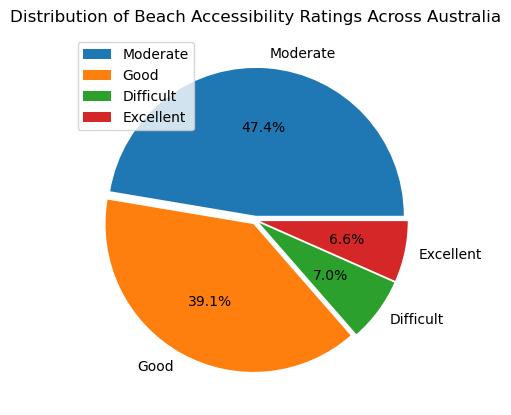

In [69]:
# Visualise accessibility rating

accesibility_num = df_aus['Accessibility'].value_counts() # Store number of each accessibility rating
pie_gap = [0.03, 0.03, 0.03, 0.03] 
plt.pie(accesibility_num, labels = accesibility_num.index, explode = pie_gap, autopct = '%1.1f%%')
plt.title('Distribution of Beach Accessibility Ratings Across Australia', pad = 10)

# Add legend
plt.legend(loc = 'upper left')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Surf'),
  Text(1, 0, 'Bay'),
  Text(2, 0, 'Lake'),
  Text(3, 0, 'River'),
  Text(4, 0, 'Ocean Pool'),
  Text(5, 0, 'Estuary'),
  Text(6, 0, 'Lagoon'),
  Text(7, 0, 'Spring'),
  Text(8, 0, 'Rockpool'),
  Text(9, 0, 'Reef'),
  Text(10, 0, 'Swell'),
  Text(11, 0, 'Pool')])

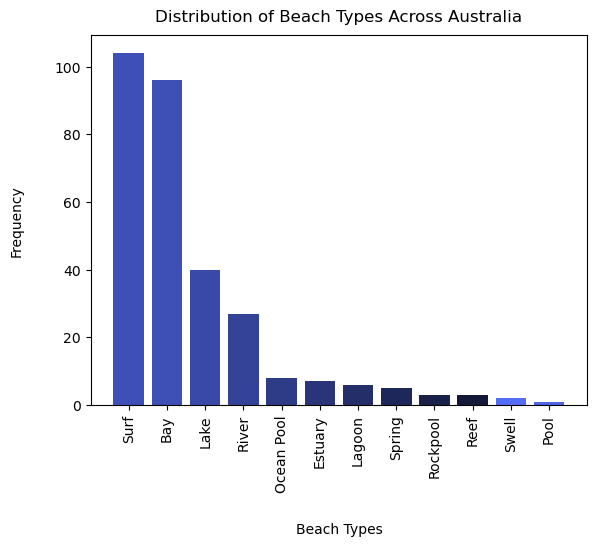

In [70]:
# Visualise beach type

beach_type_number = df_aus['Beach_Type'].value_counts()
plt.bar(beach_type_number.index, beach_type_number.values, width = 0.8, color = ['#3E50B7', '#3E4FB5', '#3949A7',
                                                                                 '#344398', '#2E3C88', '#293578',
                                                                                 '#242E69', '#1E2759', '#192049',
                                                                                 '#141939', '#546CF6', '#4E65E6'])
plt.xlabel('Beach Types', labelpad = 22)
plt.ylabel('Frequency', labelpad = 22)
plt.title('Distribution of Beach Types Across Australia', pad = 10)
plt.xticks(rotation = 90) 

## Visualise Numerical Data

Text(0.5, 1.0, 'Distribution of Average Sea Temperature In Degree Celcius Across Australia')

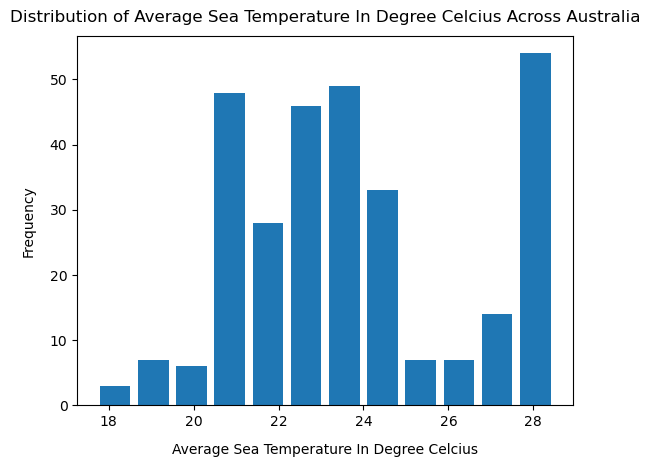

In [71]:
# Visualise avg_sea_temp_c
plt.hist(df_aus['Avg_Sea_Temp_C'], bins = 12, rwidth = 0.8)
plt.xlabel('Average Sea Temperature In Degree Celcius', labelpad = 10)
plt.ylabel('Frequency', labelpad = 10)
plt.title('Distribution of Average Sea Temperature In Degree Celcius Across Australia', pad = 10)

Text(0.5, 1.0, 'Distribution Of Average Yearly Rainfall In Millimetres Across Australia')

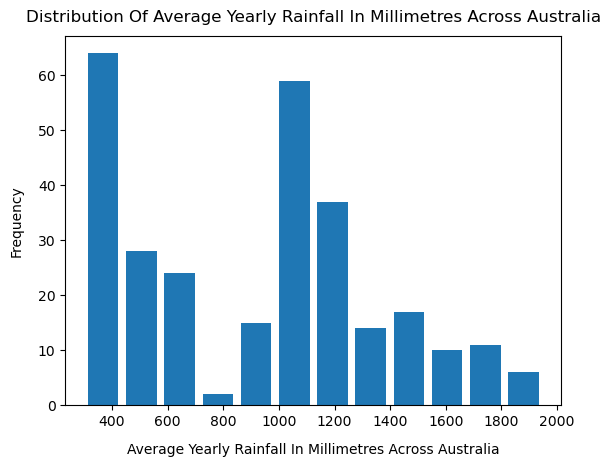

In [72]:
# Visualise annual_rainfall
plt.hist(df_aus['Annual_Rainfall_mm'], bins = 12, rwidth = 0.8)
plt.xlabel('Average Yearly Rainfall In Millimetres Across Australia', labelpad = 10)
plt.ylabel('Frequency', labelpad = 10)
plt.title('Distribution Of Average Yearly Rainfall In Millimetres Across Australia', pad = 10)

## Explore The Relationship Between Columns

### 1. Avg_Sea_Temp_C and Annual_Rainfall_mm 

In [73]:
# Descriptive Statistics

df_aus[['Avg_Sea_Temp_C', 'Annual_Rainfall_mm']].describe()

,Avg_Sea_Temp_C,Annual_Rainfall_mm
count,302.000000,287.0
mean,23.730464,911.003484
std,2.656291,445.007036
min,17.700000,300.0
25%,21.600000,469.0
50%,23.500000,1007.0
75%,25.400000,1183.0
max,28.500000,1948.0


Text(0.5, 1.0, 'Relationship Between Average Sea Temperature And Annual Rainfall')

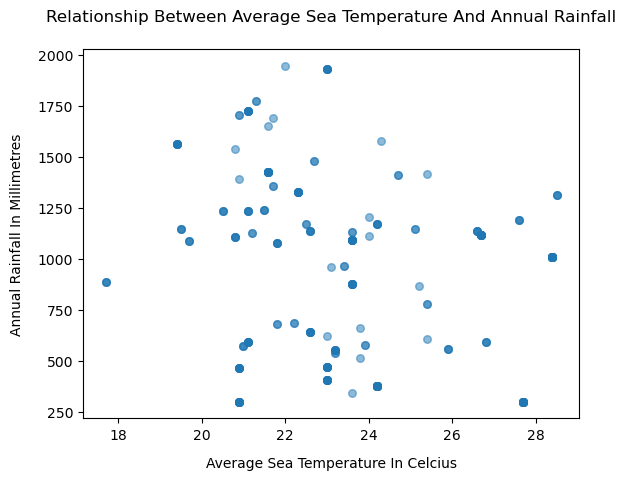

In [74]:
# Visualise the two columns using scatter plot
plt.scatter(df_aus['Avg_Sea_Temp_C'], df_aus['Annual_Rainfall_mm'], s = 30, alpha = 0.5) 
plt.xlabel('Average Sea Temperature In Celcius', labelpad = 10)
plt.ylabel('Annual Rainfall In Millimetres', labelpad = 10)
plt.title('Relationship Between Average Sea Temperature And Annual Rainfall', pad = 20)
# No clear pattern -> Might not have any relationship

In [75]:
# Double check the correlation
df_aus[['Avg_Sea_Temp_C', 'Annual_Rainfall_mm']].corr() #show negative relationship

,Avg_Sea_Temp_C,Annual_Rainfall_mm
Avg_Sea_Temp_C,1.000000,-0.232315
Annual_Rainfall_mm,-0.232315,1.000000


### 2. Accessibility and Annual_Visitors

In [76]:
# Calculate the average annual visitors and group them by the accessibility rating

visitors_accessibility = df_aus.groupby('Accessibility')['Annual_Visitors'].mean()
visitors_accessibility # The data is too skewed. Hard to visualise. 

Accessibility
Difficult      15367.761905
Excellent    2973204.388889
Good          581675.313559
Moderate        90837.58042
Name: Annual_Visitors, dtype: Float64

Text(0.5, 1.0, 'Average Annual Visitors By Accessibility Rating')

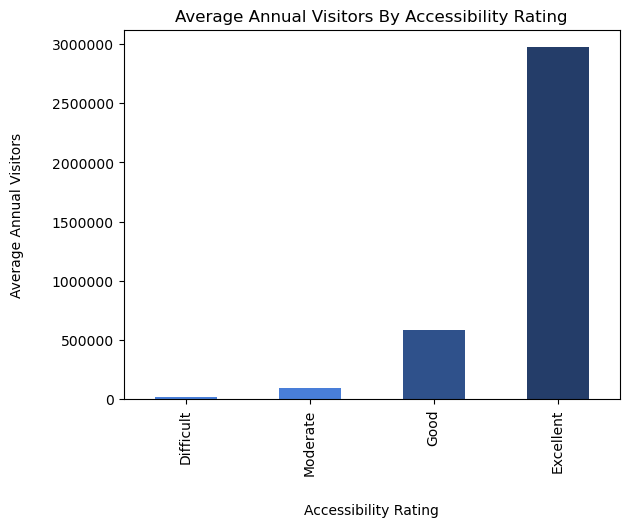

In [77]:
# Visualise overall trend
visitors_accessibility.sort_values().plot(kind = 'bar', color = ['#497ED8', '#497ED8', '#2F518B', '#243D69']) 
# sort value from smallest to highest
plt.ticklabel_format(style = 'plain', axis = 'y') # show plain numerical text, not the scientific one
plt.xlabel('Accessibility Rating', labelpad = 20)
plt.ylabel('Average Annual Visitors', labelpad = 20)
plt.title('Average Annual Visitors By Accessibility Rating')

In [78]:
# Turn Accessibility Rating to a numerical value

accessibility_num = np.select(
    [
        df_aus['Accessibility'] == 'Difficult', 
        df_aus['Accessibility'] == 'Moderate',
        df_aus['Accessibility'] == 'Good',
        df_aus['Accessibility'] == 'Excellent'
    ],
    [1, 2, 3, 4]
)

In [79]:
# Create a temporary dataframe

df_aus_temp = pd.DataFrame({'Accessibility_Rating' : accessibility_num,
                            'Annual_Visitors' : df_aus['Annual_Visitors']}).dropna() #drop null value to handle np.corrcoef

In [80]:
# Perform correlation

np.corrcoef(df_aus_temp['Accessibility_Rating'], df_aus_temp['Annual_Visitors']) # Moderate strong positive

array([[1.        , 0.69225656],
       [0.69225656, 1.        ]])

Text(0.5, 0.98, '')

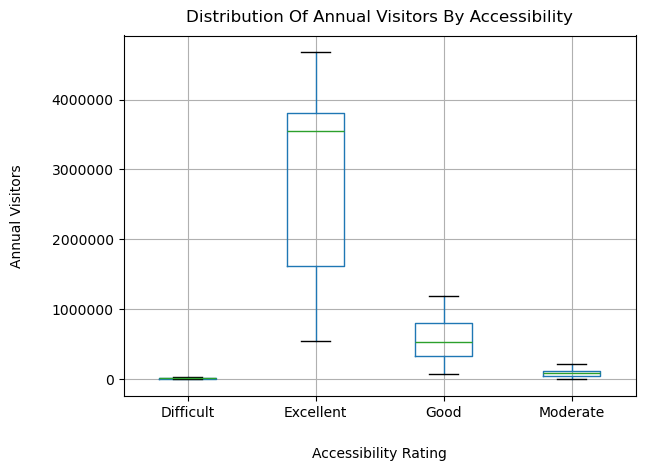

In [81]:
# Check the relationship again through a box plot
df_aus.boxplot(column = 'Annual_Visitors', by = 'Accessibility')
plt.xlabel('Accessibility Rating', labelpad = 20)
plt.ylabel('Annual Visitors', labelpad = 20)
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.title('Distribution Of Annual Visitors By Accessibility', pad = 10)
plt.suptitle('')

## Hypothesis Testing

In [82]:
# Ho: Accessibility Rating does not influence annual visitors
# H1: Accessibility Rating influences annual visitors

# Visitor values for each type of accessibility ratings

difficult_visitors_num = df_aus[df_aus['Accessibility'] == 'Difficult']['Annual_Visitors'].dropna()
moderate_visitors_num = df_aus[df_aus['Accessibility'] == 'Moderate']['Annual_Visitors'].dropna()
good_visitors_num = df_aus[df_aus['Accessibility'] == 'Good']['Annual_Visitors'].dropna()
excellent_visitors_num = df_aus[df_aus['Accessibility'] == 'Excellent']['Annual_Visitors'].dropna()

In [83]:
# ANOVA

scipy.stats.f_oneway(difficult_visitors_num, moderate_visitors_num, good_visitors_num, excellent_visitors_num)

# pvalue < 0.05 ==> reject the null. 

F_onewayResult(statistic=np.float64(316.2512902167875), pvalue=np.float64(5.741035827879577e-92))

## Filtering A Subset Of Data

In [84]:
# Filter Accessibility Rating, Facilities Rating and Water Quality Rating and Annual visitors

df_aus_filter = df_aus.filter(['Accessibility', 'Facilities_Rating', 'Water_Quality_Rating', 'Annual_Visitors'])
df_aus_filter

,Accessibility,Facilities_Rating,Water_Quality_Rating,Annual_Visitors
0,Moderate,3,4,94770.0
1,Moderate,3,4,142301.0
2,Good,4,4,854524.0
3,Excellent,5,4,3705129.0
4,Difficult,2,3,5811.0
...,...,...,...,...
297,Good,4,4,1195757.0
298,Moderate,3,3,66214.0
299,Good,4,4,565575.0
300,Good,4,4,961909.0


In [85]:
# Query for accessibility == difficult

df_aus_filter1 = df_aus_filter.query('Accessibility == "Difficult"')

In [86]:
# Query for facilities and water

df_aus_filter2 = df_aus_filter1.query('Facilities_Rating in (4, 5) | Water_Quality_Rating in (4, 5)')

C:\Users\linhc\AppData\Local\Temp\ipykernel_24076\3407216483.py:3: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  df_aus_filter2 = df_aus_filter1.query('Facilities_Rating in (4, 5) | Water_Quality_Rating in (4, 5)')


In [87]:
df_aus_filter2['Annual_Visitors'].mean().round(2) # mean visitors == 16089

np.float64(16089.16)

In [88]:
# Mean visitors for all accessibility = difficult

df_aus_filter1['Annual_Visitors'].mean().round(2) # mean visitors == 15367


np.float64(15367.76)

C:\Users\linhc\AppData\Local\Temp\ipykernel_24076\1381222954.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_aus_filter2['Annual_Visitors'], df_aus_filter1['Annual_Visitors']],


Text(0.5, 1.0, 'Comparison of Annual Visitors: High vs All Water Quality Ratings (Difficult Accessibility)')

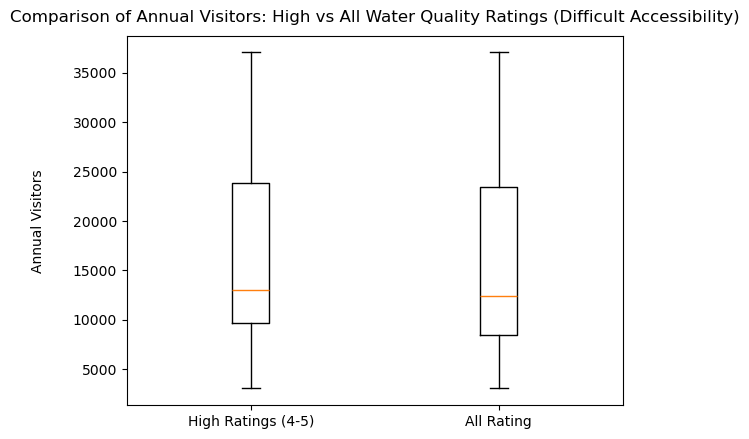

In [89]:
# Visualise the annual visitors of different water quality rating

plt.boxplot([df_aus_filter2['Annual_Visitors'], df_aus_filter1['Annual_Visitors']],
           labels = ['High Ratings (4-5)', 'All Rating'])
plt.ylabel('Annual Visitors', labelpad = 20)
plt.title('Comparison of Annual Visitors: High vs All Water Quality Ratings (Difficult Accessibility)', pad = 10)